In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
bank=pd.read_csv(r"C:\Users\divya\Downloads\Bank_Customer_Churn\Bank_Churn.csv")

In [5]:
# Display first five rows
bank.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Check for the Datatypes and null counts
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [9]:
# Statistical summary
bank.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
# Check for duplicate values
bank.duplicated().sum()

0

In [13]:
# Number of row & columns
bank.shape

(10000, 13)

In [15]:
# Check missing values
bank.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [17]:
# Remove unnecessary column
bank.drop('Surname', axis=1, inplace=True)

In [19]:
bank.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [21]:
# Check unique values distribution
bank['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [65]:
bank.to_csv(
    r"C:\Users\divya\Downloads\Bank_Customer_Churn_Clean.csv",
    index=False
)

print("Clean dataset exported successfully")

Clean dataset exported successfully


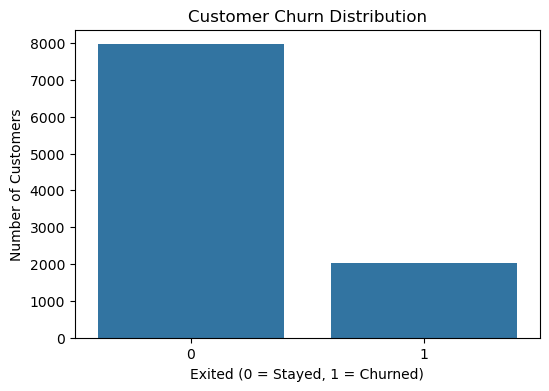

In [23]:
# Churn distribution
plt.figure(figsize=(6,4))

sns.countplot(x='Exited', data=bank)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Stayed, 1 = Churned)')
plt.ylabel('Number of Customers')

plt.savefig(r"C:\Users\divya\Downloads\Churn_project_images\churn_distribution.png", bbox_inches='tight')

plt.show()

In [25]:
# Calculate churn rate
churn_rate = (bank['Exited'].sum() / len(bank)) * 100

print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 20.37%


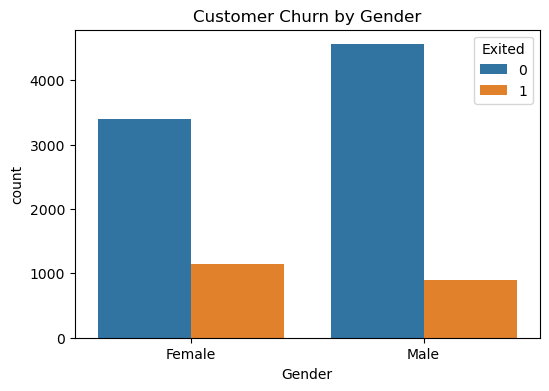

In [45]:
# Churn by Gender
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=bank
)

plt.title('Customer Churn by Gender')

plt.savefig(r"C:\Users\divya\Downloads\Churn_project_images\churn_gender.png", bbox_inches='tight')

plt.show()

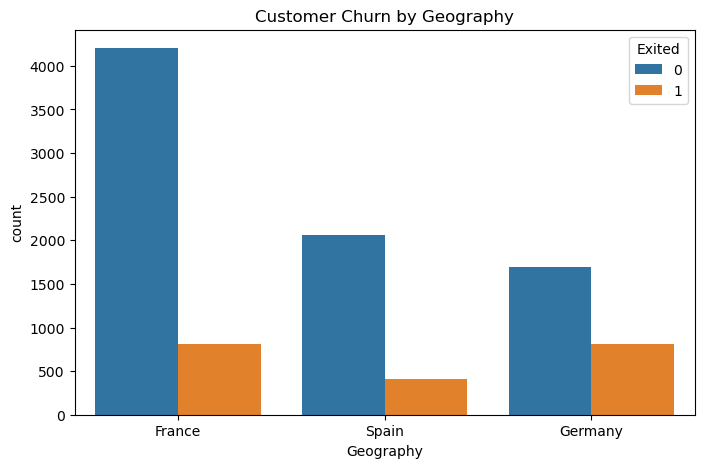

In [49]:
# Churn by geography
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=bank
)

plt.title('Customer Churn by Geography')

plt.savefig(r"C:\Users\divya\Downloads\Churn_project_images\churn_geography.png", bbox_inches='tight')

plt.show()

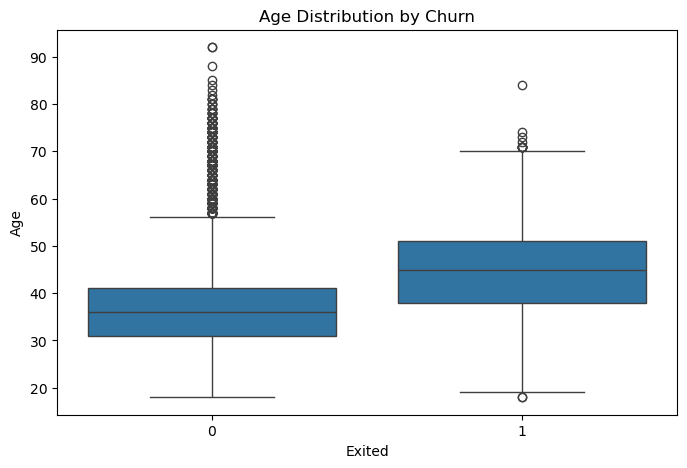

In [51]:
# Age vs Churn 
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Age',
    data=bank
)

plt.title('Age Distribution by Churn')

plt.savefig(r"C:\Users\divya\Downloads\Churn_project_images\age_churn.png", bbox_inches='tight')

plt.show()

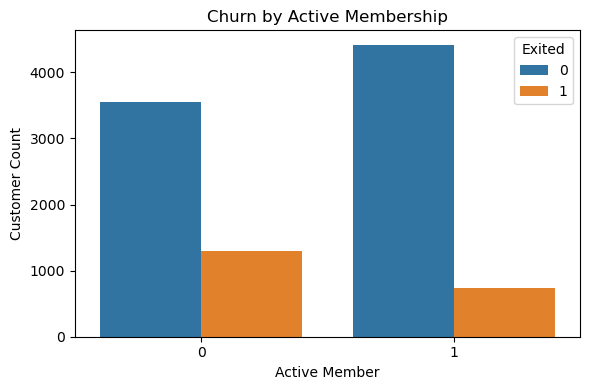

In [53]:
# Active member vs Churn
plt.figure(figsize=(6,4))

sns.countplot(
    x='IsActiveMember',
    hue='Exited',
    data=bank
)

plt.title('Churn by Active Membership')
plt.xlabel('Active Member')
plt.ylabel('Customer Count')

plt.tight_layout()

plt.savefig(
    r"C:\Users\divya\Downloads\Churn_project_images\active_member_vs_churn.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [55]:
pd.crosstab(
    bank['IsActiveMember'],
    bank['Exited'],
    normalize='index'
) * 100

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


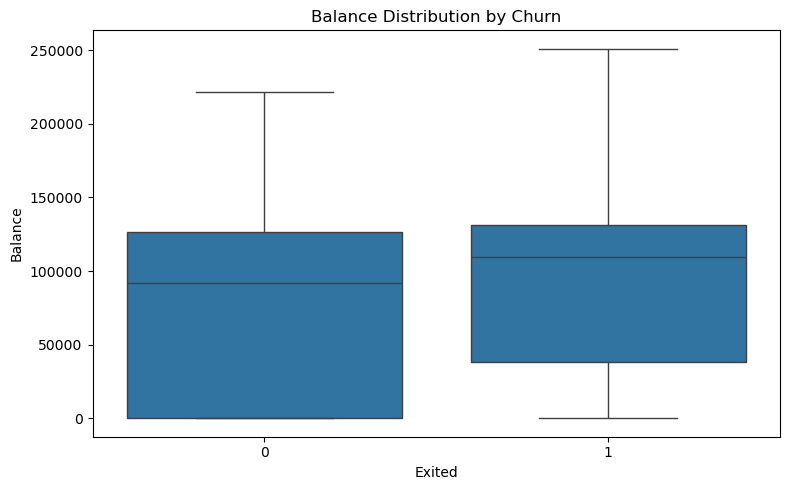

In [57]:
# Customer Balance vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=bank
)

plt.title('Balance Distribution by Churn')

plt.tight_layout()
plt.show()

In [59]:
bank.groupby('Exited')['Balance'].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

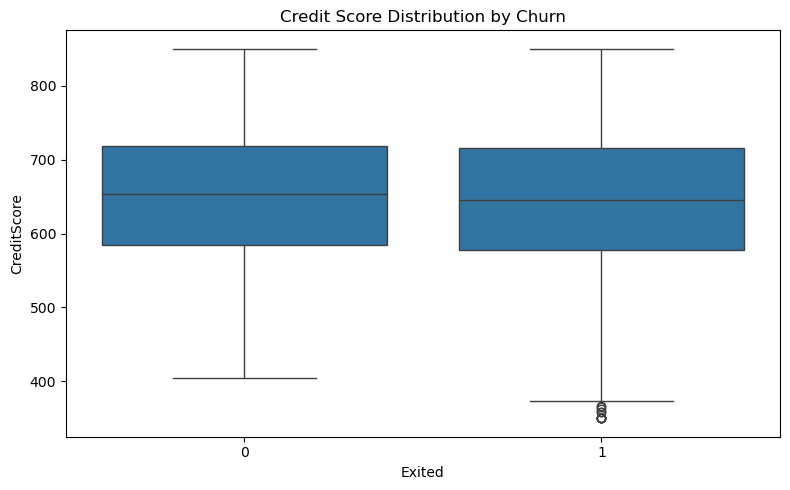

In [61]:
# Credit Score vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='CreditScore',
    data=bank
)

plt.title('Credit Score Distribution by Churn')

plt.tight_layout()
plt.show()

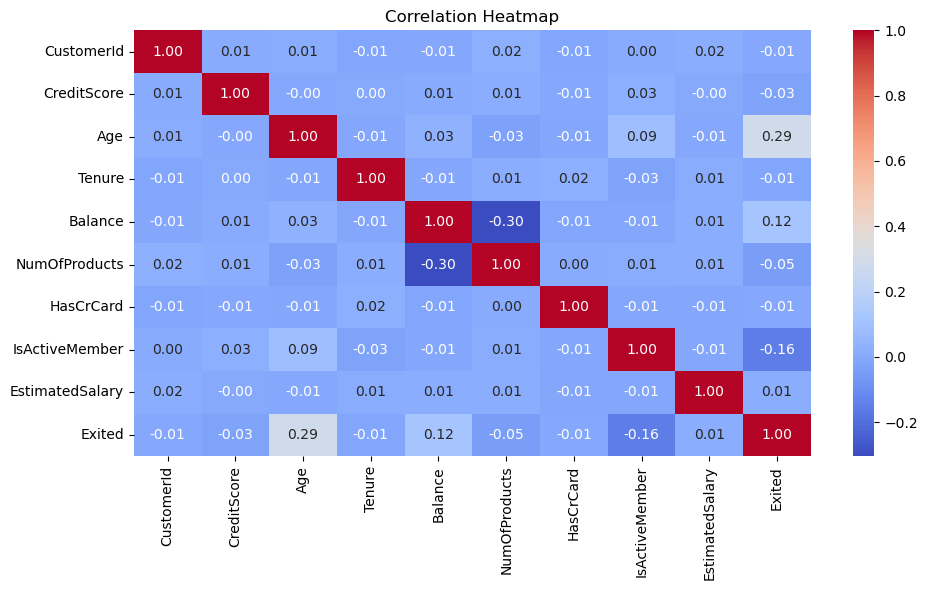

In [65]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    bank.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    r"C:\Users\divya\Downloads\Churn_project_images\correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()